<b><strong>DS 636 Final Project - Nathan Liu</b></strong>

<b>Loading Libraries</b>

In [1]:
library(plotly)
library(stringr)
library(MASS)
library(dplyr)
library(tidyr)
install.packages('tidyr')

Loading required package: ggplot2


Attaching package: 'plotly'


The following object is masked from 'package:ggplot2':

    last_plot


The following object is masked from 'package:stats':

    filter


The following object is masked from 'package:graphics':

    layout



Attaching package: 'MASS'


The following object is masked from 'package:plotly':

    select



Attaching package: 'dplyr'


The following object is masked from 'package:MASS':

    select


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union


Warning message:
"package 'tidyr' is in use and will not be installed"


<b>Loading Data</b>

In [2]:
item_categories = read.csv("FinalProjectData/item_categories.csv"); head(item_categories)
nrow(item_categories)

,item_category_name,item_category_id
,<chr>,<int>
1,PC - Гарнитуры/Наушники,0
2,Аксессуары - PS2,1
3,Аксессуары - PS3,2
4,Аксессуары - PS4,3
5,Аксессуары - PSP,4
6,Аксессуары - PSVita,5


[1] 84

In [3]:
items = read.csv("FinalProjectData/items.csv"); head(items) #item ids
nrow(items)

,item_name,item_id,item_category_id
,<chr>,<int>,<int>
1,! ВО ВЛАСТИ НАВАЖДЕНИЯ (ПЛАСТ.) D,0,40
2,"!ABBYY FineReader 12 Professional Edition Full [PC, Цифровая версия]",1,76
3,***В ЛУЧАХ СЛАВЫ (UNV) D,2,40
4,***ГОЛУБАЯ ВОЛНА (Univ) D,3,40
5,***КОРОБКА (СТЕКЛО) D,4,40
6,***НОВЫЕ АМЕРИКАНСКИЕ ГРАФФИТИ (UNI) D,5,40


[1] 22170

In [4]:
sales_train = read.csv("FinalProjectData/sales_train.csv"); head(sales_train) #training data
nrow(sales_train)

,date,date_block_num,shop_id,item_id,item_price,item_cnt_day
,<chr>,<int>,<int>,<int>,<dbl>,<dbl>
1,02.01.2013,0,59,22154,999.00,1
2,03.01.2013,0,25,2552,899.00,1
3,05.01.2013,0,25,2552,899.00,-1
4,06.01.2013,0,25,2554,1709.05,1
5,15.01.2013,0,25,2555,1099.00,1
6,10.01.2013,0,25,2564,349.00,1


[1] 2935849

In [5]:
shops = read.csv("FinalProjectData/shops.csv"); head(shops) #gives shop ids
nrow(shops)

,shop_name,shop_id
,<chr>,<int>
1,"!Якутск Орджоникидзе, 56 фран",0
2,"!Якутск ТЦ ""Центральный"" фран",1
3,"Адыгея ТЦ ""Мега""",2
4,"Балашиха ТРК ""Октябрь-Киномир""",3
5,"Волжский ТЦ ""Волга Молл""",4
6,"Вологда ТРЦ ""Мармелад""",5


[1] 60

<b>Creating New Dataframe / Model</b>

In [7]:
monthly_df = sales_train %>%
filter(date_block_num == 10 | date_block_num == 22) %>% #november 2013, november 2014
group_by(shop_id, item_id, date_block_num) %>% #groups these together for our test data
summarize(avg_cnt_month = mean(item_cnt_day), .groups = "drop") #for each unique group, calculate the mean all instances of 'item_cnt_day'.
head(monthly_df)
nrow(monthly_df)

shop_id,item_id,date_block_num,avg_cnt_month
<int>,<int>,<int>,<dbl>
2,33,10,1
2,97,10,1
2,482,10,1
2,486,22,1
2,491,22,1
2,791,10,1


[1] 97215

I want to create a model that predicts november 2015 sales by using previous november data. So, isolate our data to only include november data

In [8]:
predict_df = select(monthly_df, -date_block_num); head(predict_df) #removes months to prepare data for combination
predict_df = predict_df %>%
group_by(shop_id, item_id) %>%
summarize(avg_cnt_november = mean(avg_cnt_month), .groups = "drop") #takes the averages of the duplicates (representing 2013 and 2014), and average them for 2015
head(predict_df)

shop_id,item_id,avg_cnt_month
<int>,<int>,<dbl>
2,33,1
2,97,1
2,482,1
2,486,1
2,491,1
2,791,1


shop_id,item_id,avg_cnt_november
<int>,<int>,<dbl>
2,33,1
2,97,1
2,482,1
2,486,1
2,491,1
2,791,1


creates a dataframe, which would resemble november 2015 by combining the two instances of data for november 2013 and november 2014 and averaging them.

<b>Testing Our Model</b>

In [9]:
test = read.csv("FinalProjectData/test.csv"); head(test)

,ID,shop_id,item_id
,<int>,<int>,<int>
1,0,5,5037
2,1,5,5320
3,2,5,5233
4,3,5,5232
5,4,5,5268
6,5,5,5039


In [20]:
test_df = merge(test, predict_df, by = c("shop_id", "item_id"), all.x = TRUE); head(test_df); nrow(test_df); nrow(test)
#merge all avg_cnt_november to respective 'shop_id' and 'item_id' combos, with all unmatches being 'NA'

,shop_id,item_id,ID,avg_cnt_november
,<int>,<int>,<int>,<dbl>
1,2,30,22987,NA
2,2,31,20994,NA
3,2,32,20995,NA
4,2,33,22492,1
5,2,38,22491,NA
6,2,42,22490,NA


[1] 214200

[1] 214200

merge and match any shop_id and item_id combo from our prediction dataframe and combine them here. any unmatched values will be "NA". 

In [21]:
final_df = test_df %>% #preping our submission_df
replace_na(list(avg_cnt_november = 0)); head(final_df) #replaces NA with 0

,shop_id,item_id,ID,avg_cnt_november
,<int>,<int>,<int>,<dbl>
1,2,30,22987,0
2,2,31,20994,0
3,2,32,20995,0
4,2,33,22492,1
5,2,38,22491,0
6,2,42,22490,0


since we can't match the data for new 'shop_id' and 'item_id' combos, we assume they are 0.

In [22]:
colnames(final_df)[colnames(final_df) == 'avg_cnt_november'] = 'item_cnt_month' 
final_df = select(final_df, -c(item_id, shop_id))
final_df = arrange(final_df, ID); final_df #sorts by ID

ID,item_cnt_month
<int>,<dbl>
0,1.000000
1,0.000000
2,0.000000
3,0.000000
4,0.000000
5,0.000000
6,0.000000
7,1.000000
8,5.000000


preparing our data for submission

In [13]:
sample_submission = read.csv("FinalProjectData/sample_submission.csv"); head(sample_submission)
nrow(sample_submission)

,ID,item_cnt_month
,<int>,<dbl>
1,0,0.5
2,1,0.5
3,2,0.5
4,3,0.5
5,4,0.5
6,5,0.5


[1] 214200

In [14]:
write.csv(final_df,"liu_sample_submission.csv", row.names = FALSE) #creates file for submission

With this model, we get a score of 1.25777. how should we improve upon it?

we can fill out some other NAs with averages from other months. 

In [16]:
new_monthly_df = sales_train %>%
filter(date_block_num != 10 | date_block_num != 22) %>% #months other than november
group_by(shop_id, item_id, date_block_num) %>% #groups these together for our test data
summarize(avg_cnt_month = mean(item_cnt_day), .groups = "drop") %>%#for each unique group, calculate the mean all instances of 'item_cnt_day'.
anti_join(monthly_df, by = c("shop_id", "item_id"))#prevents overlap of data, so we can predict new things exclusive from november 'shop_id' and 'item_id'
head(new_monthly_df)
nrow(new_monthly_df)

shop_id,item_id,date_block_num,avg_cnt_month
<int>,<int>,<int>,<dbl>
0,30,1,3.444444
0,31,1,1.571429
0,32,0,1.500000
0,32,1,1.428571
0,33,0,1.000000
0,33,1,1.000000


[1] 909548

with our new dataframe, we'll remove the individual months (date_block_num), and just look at the averages for each 'shop_id' and 'item_id' combo monthly.

In [17]:
new_monthly_df = new_monthly_df %>%
select(-date_block_num) %>%
group_by(shop_id, item_id) %>%
summarize(avg_cnt_total = mean(avg_cnt_month), .groups = "drop")
head(new_monthly_df)
nrow(new_monthly_df)

shop_id,item_id,avg_cnt_total
<int>,<int>,<dbl>
0,30,3.444444
0,31,1.571429
0,32,1.464286
0,33,1.000000
0,35,1.136364
0,36,1.000000


[1] 336191

with this, we can create a new testing dataframe with our avg_cnt_total column

In [18]:
new_test_df = merge(test, new_monthly_df, all.x=TRUE); head(new_test_df)#preserves # of rows
nrow(new_test_df)

,shop_id,item_id,ID,avg_cnt_total
,<int>,<int>,<int>,<dbl>
1,2,30,22987,1
2,2,31,20994,1
3,2,32,20995,1
4,2,33,22492,NA
5,2,38,22491,NA
6,2,42,22490,NA


[1] 214200

In [23]:
merged_test_df = left_join(new_test_df, test_df, by = c('shop_id', 'item_id')); head(merged_test_df) #joins the two dataframes together, creating two separate columns for each.
nrow(merged_test_df)

,shop_id,item_id,ID.x,avg_cnt_total,ID.y,avg_cnt_november
,<int>,<int>,<int>,<dbl>,<int>,<dbl>
1,2,30,22987,1,22987,NA
2,2,31,20994,1,20994,NA
3,2,32,20995,1,20995,NA
4,2,33,22492,NA,22492,1
5,2,38,22491,NA,22491,NA
6,2,42,22490,NA,22490,NA


[1] 214200

now, we want to coalesce the 'avg_cnt_total' and 'avg_cnt_november' to combine the columns

In [24]:
merged_test_df = mutate(merged_test_df, item_cnt_month = coalesce(avg_cnt_total, avg_cnt_november)) #creates a new row 'item_cnt_month' for our final df. Basically, combines both 'avg' dataframes to get one cohesive one

In [25]:
merged_test_df = merged_test_df %>%
select(-avg_cnt_total, -avg_cnt_november, -ID.y, -shop_id, -item_id) #removes unnecessary columns

head(merged_test_df)

,ID.x,item_cnt_month
,<int>,<dbl>
1,22987,1
2,20994,1
3,20995,1
4,22492,1
5,22491,NA
6,22490,NA


In [26]:
colnames(merged_test_df)[colnames(merged_test_df) == 'ID.x'] = 'ID'; head(merged_test_df) #changes ID name

,ID,item_cnt_month
,<int>,<dbl>
1,22987,1
2,20994,1
3,20995,1
4,22492,1
5,22491,NA
6,22490,NA


In [27]:
merged_test_df = merged_test_df %>%
replace_na(list(item_cnt_month = 0)) %>% #replaces all NA's with 0, just as we did with previous dataframe
arrange(ID) #arrange in id number

In [28]:
merged_test_df #final df

ID,item_cnt_month
<int>,<dbl>
0,1.000000
1,0.000000
2,1.100000
3,1.000000
4,0.000000
5,1.000000
6,1.000000
7,1.000000
8,5.000000


In [29]:
write.csv(merged_test_df,"liu_sample_submission_2.csv", row.names = FALSE) #creates file for submission

with this submission, our score actually went up: 1.28584 from 1.25777.

so, maybe not such a good model...

we can try using a linear model regression for unknown values then.

In [30]:
monthly_df = sales_train %>% #creates a new monthly dataframe with sum instead of avg, as we'll use the avg for our 'features'
group_by(shop_id, item_id, date_block_num) %>% 
summarize(item_cnt_month = sum(item_cnt_day), .groups = "drop"); head(monthly_df)
nrow(monthly_df)

shop_id,item_id,date_block_num,item_cnt_month
<int>,<int>,<int>,<dbl>
0,30,1,31
0,31,1,11
0,32,0,6
0,32,1,10
0,33,0,3
0,33,1,3


[1] 1609124

feature creation, we'll use the averages as our features (both for november and all the months)

In [31]:
nov_avg = monthly_df %>%
filter(date_block_num == 10 | date_block_num == 22) %>%
group_by(shop_id, item_id) %>%
summarise(nov_avg = mean(item_cnt_month), .groups = "drop")
head(nov_avg)
nrow(nov_avg)

shop_id,item_id,nov_avg
<int>,<int>,<dbl>
2,33,2
2,97,1
2,482,2
2,486,2
2,491,1
2,791,1


[1] 87933

In [32]:
month_avg = monthly_df %>%
group_by(shop_id, item_id) %>%
summarise(month_avg = mean(item_cnt_month), .groups = "drop")
head(month_avg)
nrow(month_avg)

shop_id,item_id,month_avg
<int>,<int>,<dbl>
0,30,31.0
0,31,11.0
0,32,8.0
0,33,3.0
0,35,7.5
0,36,1.0


[1] 424124

In [33]:
features = monthly_df %>% #joins our features and main df, so we can predict 'item_cnt_month' from main df, and have our features in same df
left_join(nov_avg, by = c("shop_id", "item_id")) %>%
left_join(month_avg, by = c("shop_id", "item_id")) %>%
mutate(has_nov = ifelse(is.na(nov_avg), 0, 1)) %>% #has_nov will add more 'weight' if we do have november data
replace_na(list(nov_avg = 0)); #replaces NAs
head(features)
nrow(features)

shop_id,item_id,date_block_num,item_cnt_month,nov_avg,month_avg,has_nov
<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
0,30,1,31,0,31,0
0,31,1,11,0,11,0
0,32,0,6,0,8,0
0,32,1,10,0,8,0
0,33,0,3,0,3,0
0,33,1,3,0,3,0


[1] 1609124

with our features ready, we can use lm() function to create a model

In [34]:
regression_model = lm(item_cnt_month ~ nov_avg + month_avg + has_nov, data = features)
#predicted value (y) = item_cnt_month
#nov_avg = will add 'weight' and shift predicted value using month_avg as baseline
#month_avg = the'meat' of our data, as most of our predictions will use this
#has_nov = adds additionally 'weight' if we have november data
#hopefully, with our intercept, we can have a more accurate model for unknown ids?

In [35]:
summary(regression_model)


Call:
lm(formula = item_cnt_month ~ nov_avg + month_avg + has_nov, 
    data = features)

Residuals:
   Min     1Q Median     3Q    Max 
-651.5   -0.5    0.0    0.0 2060.0 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept)  3.657e-11  6.264e-03     0.0        1    
nov_avg      1.680e-12  9.329e-04     0.0        1    
month_avg    1.000e+00  1.267e-03   789.1   <2e-16 ***
has_nov     -2.835e-15  9.089e-03     0.0        1    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 5.599 on 1609120 degrees of freedom
Multiple R-squared:  0.581,	Adjusted R-squared:  0.581 
F-statistic: 7.438e+05 on 3 and 1609120 DF,  p-value: < 2.2e-16


we can see november data (nov_avg, has_nov) doens't really have much of an effect on our predicted values based on the coefficients

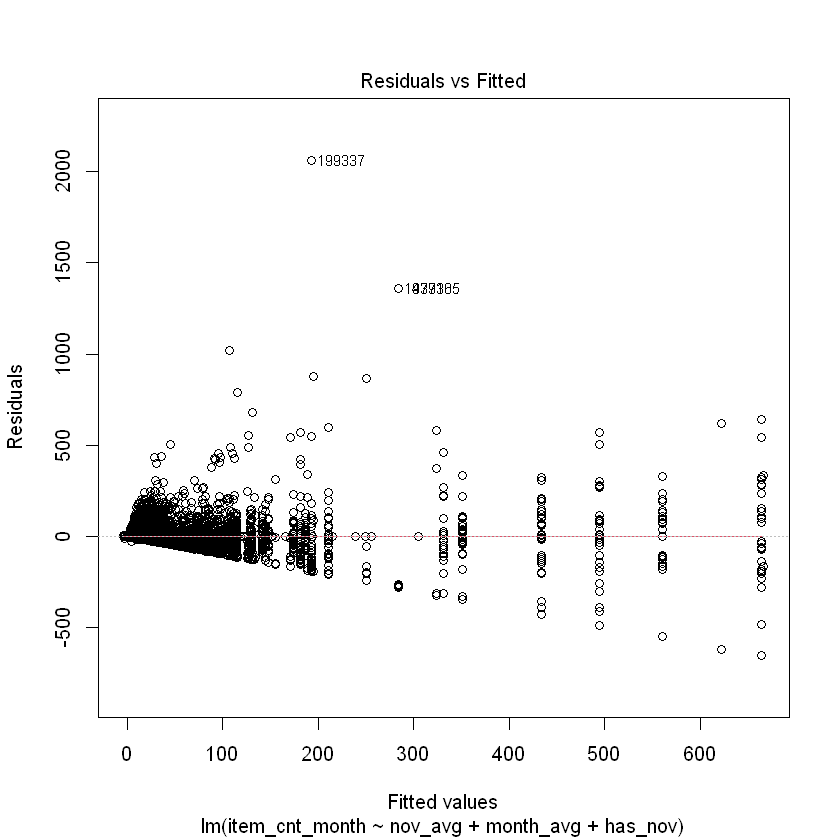

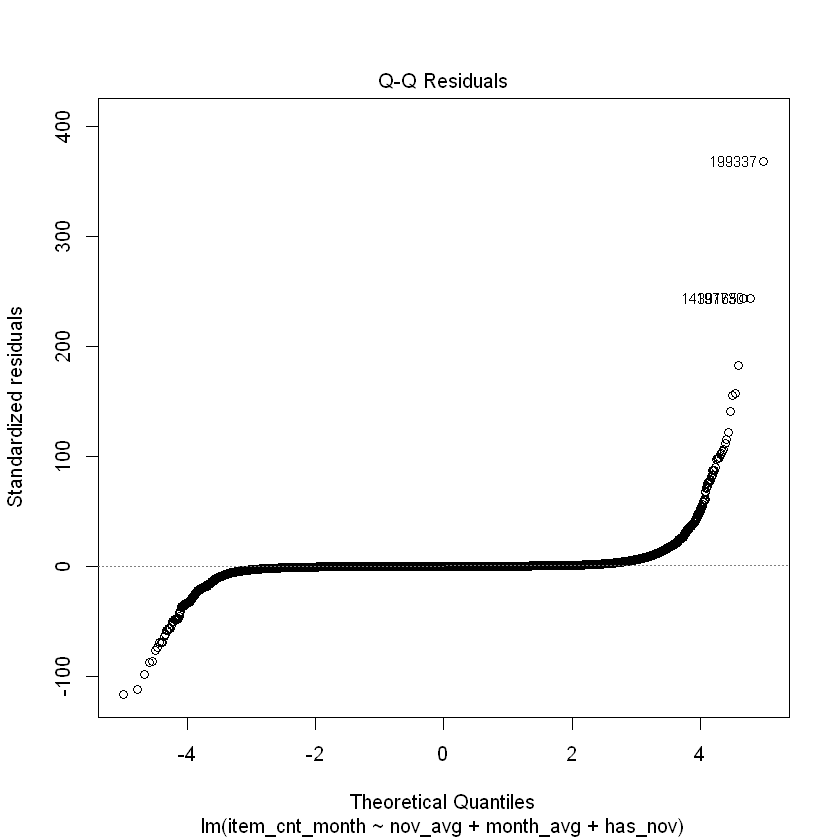

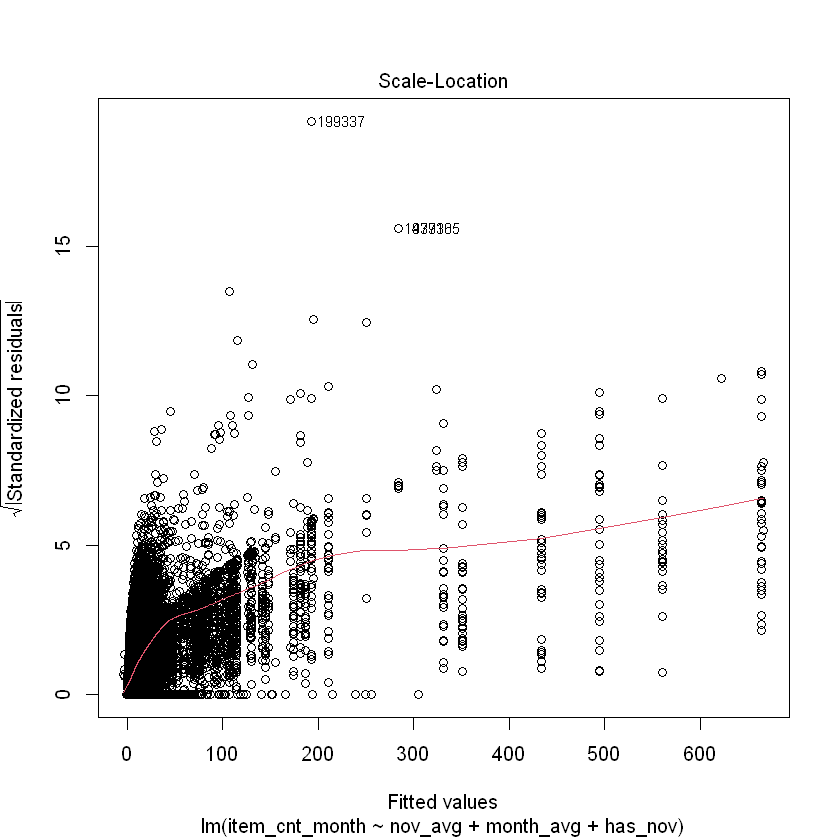

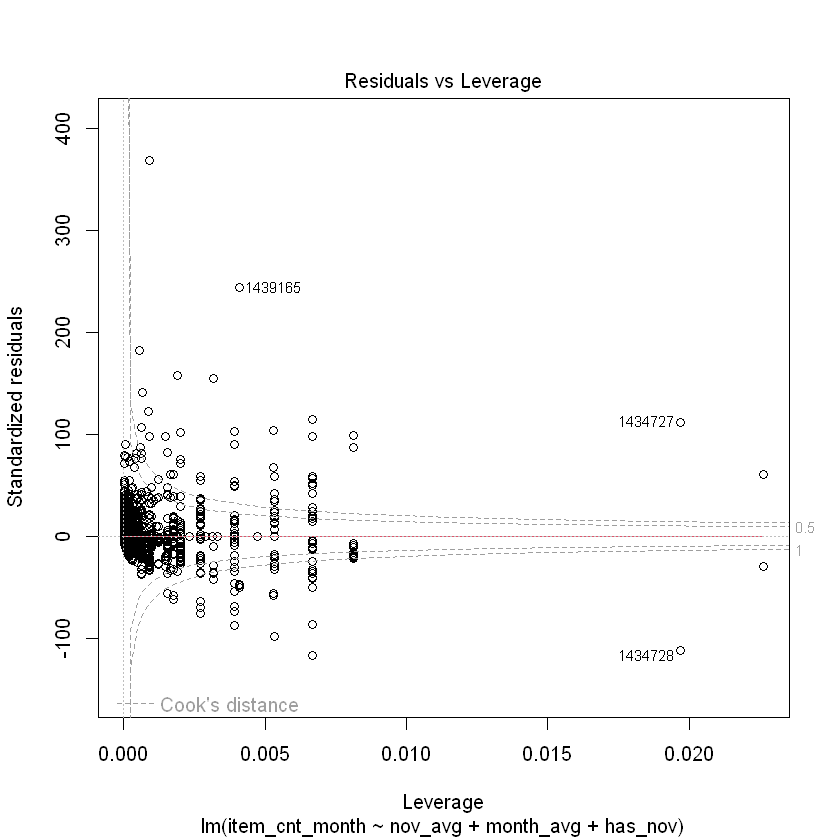

In [36]:
plot(regression_model)

i don't understand all these graphs, but our residuals look relatively randomly scattered, so model isn't a bad choice?

Applying our model to test data

In [43]:
test_model_df = test %>% #same premise here, add features to test data
left_join(nov_avg, by = c("shop_id", "item_id")) %>%
left_join(month_avg, by = c("shop_id", "item_id")) %>%
mutate(has_nov = ifelse(is.na(nov_avg), 0, 1)) %>%
replace_na(list(nov_avg = 0, month_avg = 0)); head(test_model_df)
nrow(test_model_df)

,ID,shop_id,item_id,nov_avg,month_avg,has_nov
,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>
1,0,5,5037,1,1.444444,1
2,1,5,5320,0,0.000000,0
3,2,5,5233,0,2.000000,0
4,3,5,5232,0,1.000000,0
5,4,5,5268,0,0.000000,0
6,5,5,5039,0,1.833333,0


[1] 214200

now, we can use the prediction() function to generate item_cnt_month values from our model

In [44]:
prediction_cnt = predict(regression_model, newdata = test_model_df)
length(prediction_cnt) #verifies same number of rows 
prediction_cnt

[1] 214200

1            2            3            4            5            6 
1.444444e+00 3.657070e-11 2.000000e+00 1.000000e+00 3.657070e-11 1.833333e+00 
           7            8            9           10           11           12 
2.500000e+00 2.000000e+00 5.727273e+00 3.657070e-11 3.650000e+00 1.000000e+00 
          13           14           15           16           17           18 
1.000000e+00 2.571429e+00 3.629630e+00 4.388889e+00 3.657070e-11 1.000000e+00 
          19           20           21           22           23           24 
3.571429e+00 2.500000e+00 3.000000e+00 3.657070e-11 2.960000e+00 2.000000e+00 
          25           26           27           28           29           30 
2.125000e+00 3.657070e-11 3.657070e-11 1.555556e+00 2.250000e+00 5.000000e+00 
          31           32           33           34           35           36 
1.875000e+00 3.657070e-11 1.846154e+00 3.555556e+00 2.000000e+00 1.000000e+00 
          37           38           39           40           41           42 
6.666667e-01 2.000000e+00 1.000000e+00 1.000000e+00 1.500000e+00 2.666667e+00 
          43           44           45           46           47           48 
3.187500e+00 5.451613e+00 1.500000e+00 3.657070e-11 4.000000e+00 1.750000e+00 
          49           50           51           52           53           54 
1.333333e+00 2.181818e+00 3.400000e+00 1.000000e+00 1.166667e+00 1.000000e+00 
          55           56           57           58           59           60 
2.071429e+01 7.500000e+00 5.692308e+00 4.142857e+00 1.150000e+01 1.350000e+01 
          61           62           63           64           65           66 
8.500000e+00 2.000000e+00 1.333333e+00 1.333333e+00 3.657070e-11 3.657070e-11 
          67           68           69           70           71           72 
1.714286e+00 1.000000e+00 1.500000e+00 1.466667e+00 3.657070e-11 5.000000e+00 
          73           74           75           76           77           78 
1.125000e+00 5.800000e+00 3.657070e-11 3.657070e-11 1.500000e+00 3.657070e-11 
          79           80           81           82           83           84 
1.736842e+00 2.500000e+00 2.500000e+00 5.285714e+00 3.333333e+00 1.500000e+00 
          85           86           87           88           89           90 
2.458333e+00 1.913043e+00 1.652174e+00 1.200000e+00 6.875000e+00 3.888889e+00 
          91           92           93           94           95           96 
1.800000e+00 1.000000e+00 5.800000e+00 1.000000e+00 3.500000e+00 1.000000e+00 
          97           98           99          100          101          102 
1.000000e+00 1.416667e+00 1.785714e+00 8.956522e+00 9.000000e+00 2.000000e+00 
         103          104          105          106          107          108 
1.300000e+00 1.000000e+00 1.000000e+00 3.657070e-11 3.657070e-11 5.769231e+00 
         109          110          111          112          113          114 
1.000000e+00 3.657070e-11 1.333333e+00 3.657070e-11 3.657070e-11 3.657070e-11 
         115          116          117          118          119          120 
1.571429e+00 1.200000e+00 3.657070e-11 1.000000e+00 1.121429e+01 1.000000e+00 
         121          122          123          124          125          126 
2.000000e+00 1.000000e+00 1.428571e+00 1.818182e+00 2.000000e+00 1.500000e+00 
         127          128          129          130          131          132 
3.657070e-11 2.000000e+00 3.657070e-11 1.000000e+00 1.000000e+00 3.657070e-11 
         133          134          135          136          137          138 
1.000000e+00 8.000000e+00 1.000000e+00 1.000000e+00 1.000000e+00 3.657070e-11 
         139          140          141          142          143          144 
1.600000e+00 3.657070e-11 1.500000e+00 1.500000e+00 1.000000e+00 1.000000e+00 
         145          146          147          148          149          150 
3.657070e-11 3.657070e-11 3.657070e-11 1.200000e+00 3.657070e-11 3.657070e-11 
         151          152          153          154          

In [45]:
test_model_df$item_cnt_month = prediction_cnt #adds row to df

In [46]:
test_model_df = test_model_df %>%
select(-c('shop_id', 'item_id', 'nov_avg', 'month_avg', 'has_nov')); 
test_model_df
#preps dataframe for submission

ID,item_cnt_month
<int>,<dbl>
0,1.444444e+00
1,3.657070e-11
2,2.000000e+00
3,1.000000e+00
4,3.657070e-11
5,1.833333e+00
6,2.500000e+00
7,2.000000e+00
8,5.727273e+00


In [41]:
write.csv(test_model_df,"liu_sample_submission_3.csv", row.names = FALSE) #creates file for submission

we actually get a pretty bad score (2.94933) with this model compared with just our average models (1.257 and 1.285). Funnily enough, just looking at the averages for november, and filling the rest of the data with 0s was the most 'accurate' approach.

As a final approach, I want to just look at the november averages and create a model based off that.

In [47]:
regression_model_2 = lm(item_cnt_month ~ nov_avg, data = features)

In [48]:
summary(regression_model_2)


Call:
lm(formula = item_cnt_month ~ nov_avg, data = features)

Residuals:
    Min      1Q  Median      3Q     Max 
-531.68   -1.03   -0.41   -0.03 2041.50 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) 1.4145640  0.0052660   268.6   <2e-16 ***
nov_avg     0.6169973  0.0005749  1073.2   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 6.603 on 1609122 degrees of freedom
Multiple R-squared:  0.4172,	Adjusted R-squared:  0.4172 
F-statistic: 1.152e+06 on 1 and 1609122 DF,  p-value: < 2.2e-16


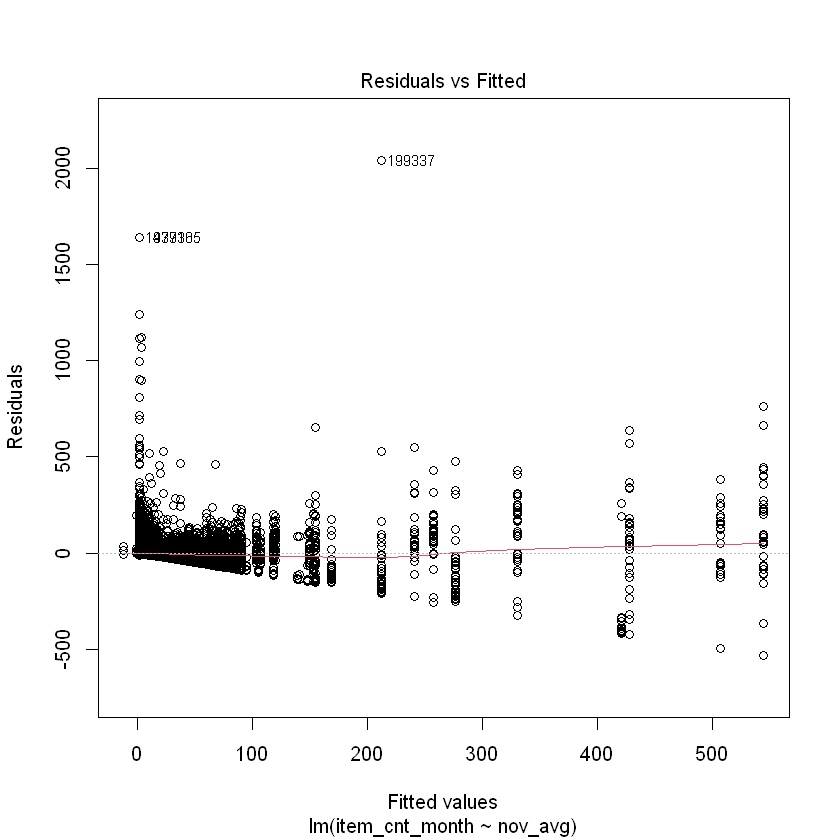

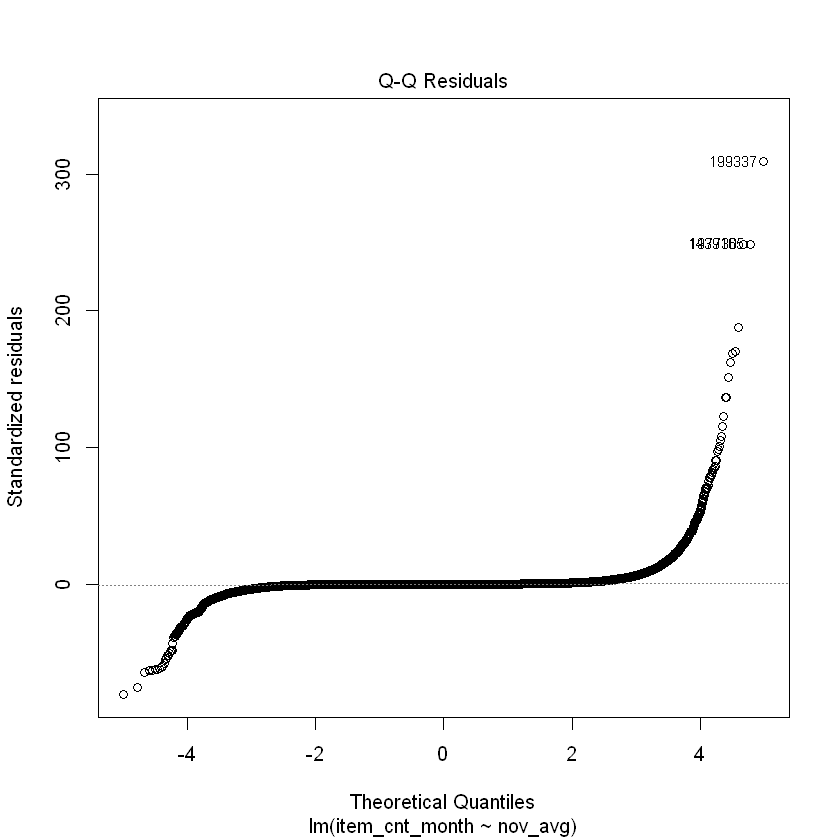

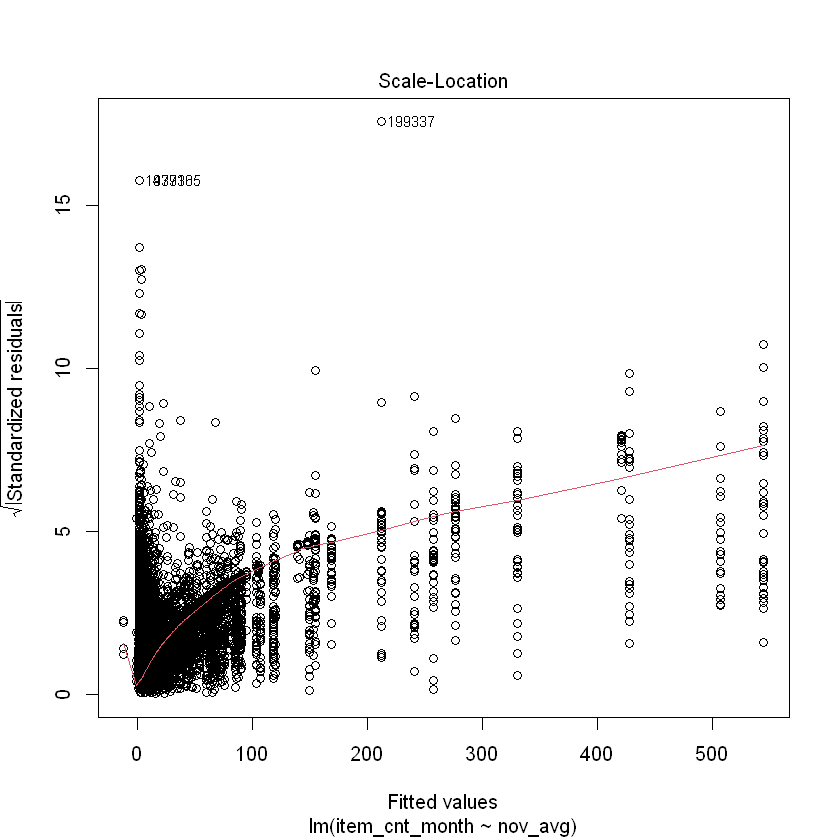

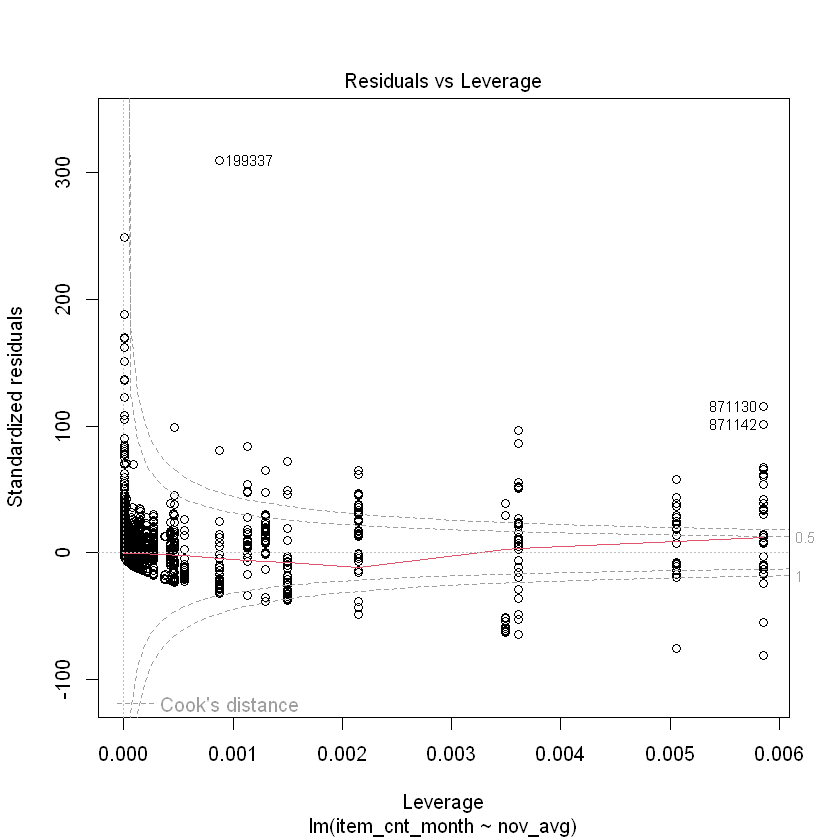

In [49]:
plot(regression_model_2)

In [50]:
test_model_df_2 = test %>%
left_join(nov_avg, by = c("shop_id", "item_id")) %>%
replace_na(list(nov_avg = 0, month_avg = 0)); head(test_model_df_2)

,ID,shop_id,item_id,nov_avg
,<int>,<int>,<int>,<dbl>
1,0,5,5037,1
2,1,5,5320,0
3,2,5,5233,0
4,3,5,5232,0
5,4,5,5268,0
6,5,5,5039,0


In [51]:
prediction_cnt_2 = predict(regression_model_2, newdata = test_model_df_2)
length(prediction_cnt)

[1] 214200

In [52]:
test_model_df_2$item_cnt_month = prediction_cnt_2

In [53]:
test_model_df_2 = test_model_df_2 %>%
select(-c('shop_id', 'item_id', 'nov_avg'))
test_model_df_2

ID,item_cnt_month
<int>,<dbl>
0,2.031561
1,1.414564
2,1.414564
3,1.414564
4,1.414564
5,1.414564
6,1.414564
7,2.031561
8,4.499550


In [54]:
write.csv(test_model_df_2,"liu_sample_submission_4.csv", row.names = FALSE)

and with this final submission, our score becomes 2.82374 (marginally better than our previous model).